## --- Generate text with a recurrent neural network (Pytorch) ---
### (Mostly Read & Run)

The goal is to replicate the (famous) experiment from [Karpathy's blog](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

To learn to generate text, we train a recurrent neural network to do the following task:

Given a "chunk" of text: `this is random text`

the goal of the network is to predict each character in **`his is random text` ** sequentially given the following sequential input **`this is random tex`**:




## Load text (dataset/input.txt)

Before building training batch, we load the full text in RAM

In [1]:
!wget https://thome.isir.upmc.fr/classes/RITAL/input.txt

--2026-03-16 14:16:32--  https://thome.isir.upmc.fr/classes/RITAL/input.txt
Resolving thome.isir.upmc.fr (thome.isir.upmc.fr)... 134.157.18.247
Connecting to thome.isir.upmc.fr (thome.isir.upmc.fr)|134.157.18.247|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  70.5KB/s    in 13s     

2026-03-16 14:16:50 (83.2 KB/s) - ‘input.txt’ saved [1115394/1115394]



In [ ]:
#! pip install unidecode

In [2]:
import unidecode
import string
import random
import re
import torch
import torch.nn as nn

all_characters = string.printable
n_characters = len(all_characters)

file = unidecode.unidecode(open('./input.txt').read()) #clean text => only ascii
file_len = len(file)
print('file_len =', file_len)


file_len = 1115394


## 2: Helper functions:

We have a text and we want to feed batch of chunks to a neural network:

one chunk  A,B,C,D,E
[input] A,B,C,D -> B,C,D,E [output]

Note: we will use an embedding layer instead of a one-hot encoding scheme.

for this, we have 3 functions:

- One to get a random str chunk of size `chunk_len` : `random_chunk`
- One to turn a chunk into a tensor of size `(1,chunk_len)` coding for each characters : `char_tensor`
- One to return random input and output chunks of size `(batch_size,chunk_len)` : `random_training_set`




In [3]:
import time, math


#Get a piece of text
def random_chunk(chunk_len):
    start_index = random.randint(0, file_len - chunk_len)
    end_index = start_index + chunk_len + 1
    return file[start_index:end_index]


# Turn string into list of longs
def char_tensor(string):
    tensor = torch.zeros(1,len(string)).long()
    for c in range(len(string)):
        tensor[0,c] = all_characters.index(string[c])
    return tensor


#Turn a piece of text in train/test
def random_training_set(chunk_len=200, batch_size=8):
    chunks = [random_chunk(chunk_len) for _ in range(batch_size)]
    inp = torch.cat([char_tensor(chunk[:-1]) for chunk in chunks],dim=0)
    target = torch.cat([char_tensor(chunk[1:]) for chunk in chunks],dim=0)

    return inp, target

print(random_training_set(10,4))  ## should return 8 chunks of 10 letters.

(tensor([[94, 12, 17, 18, 21, 13, 73, 94, 21, 14],
        [10, 23, 13, 94, 23, 24, 29, 94, 15, 24],
        [56, 47, 44, 40, 55, 77, 96, 50, 73, 94],
        [24, 30, 28, 75, 96, 96, 57, 44, 49, 38]]), tensor([[12, 17, 18, 21, 13, 73, 94, 21, 14, 29],
        [23, 13, 94, 23, 24, 29, 94, 15, 24, 27],
        [47, 44, 40, 55, 77, 96, 50, 73, 94, 15],
        [30, 28, 75, 96, 96, 57, 44, 49, 38, 40]]))


## The actual RNN model (only thing to complete):

It should be composed of three distinct modules:

- an [embedding layer](https://pytorch.org/docs/stable/nn.html#embedding) (n_characters, hidden_size)

```
nn.Embedding(len_dic,size_vec)
```
- a [recurrent](https://pytorch.org/docs/stable/nn.html#recurrent-layers) layer (hidden_size, hidden_size)
```
nn.RNN(in_size,out_size) or nn.GRU() or nn.LSTM() => rnn_cell parameter
```
- a [prediction](https://pytorch.org/docs/stable/nn.html#linear) layer (hidden_size, output_size)

```
nn.Linear(in_size,out_size)
```
=> Complete the `init` function code

In [4]:
import torch.nn.functional as f

class RNN(nn.Module):

    def __init__(self, n_char, hidden_size, output_size, n_layers=1,rnn_cell=nn.RNN):
        """
        Create the network
        """
        super(RNN, self).__init__()

        self.n_char = n_char
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers

        #  (batch,chunk_len) -> (batch, chunk_len, hidden_size)
        self.embed = nn.Embedding(n_characters,hidden_size)

        # (batch, chunk_len, hidden_size)  -> (batch, chunk_len, hidden_size)
        self.rnn = rnn_cell(hidden_size,hidden_size)
        #(batch, chunk_len, hidden_size) -> (batch, chunk_len, output_size)
        self.predict = nn.Linear(hidden_size,output_size)

    def forward(self, input):
        """
        batched forward: input is (batch > 1,chunk_len)
        """
        input = self.embed(input)
        output,_  = self.rnn(input)
        output = self.predict(f.tanh(output))
        return output

    def forward_seq(self, input,hidden=None):
        """
        not batched forward: input is  (1,chunk_len)
        """
        input = self.embed(input)
        output,hidden  = self.rnn(input.unsqueeze(0),hidden)
        output = self.predict(f.tanh(output))
        return output,hidden


## Text generation function

Sample text from the model

In [11]:
def generate(model,device,prime_str='A', predict_len=100, temperature=0.8,):
    prime_input = char_tensor(prime_str).squeeze(0).to(device)
    hidden = None
    predicted = prime_str+""
    # Use priming string to "build up" hidden state

    for p in range(len(prime_str)-1):
        _,hidden = model.forward_seq(prime_input[p].unsqueeze(0),hidden)

    #print(hidden.size())
    for p in range(predict_len):
        output, hidden = model.forward_seq(prime_input[-1].unsqueeze(0), hidden)
                # Sample from the network as a multinomial distribution
        output_dist = output.data.view(-1).div(temperature).exp()
        #print(output_dist)
        top_i = torch.multinomial(output_dist, 1)[0]
        #print(top_i)
        # Add predicted character to string and use as next input
        predicted_char = all_characters[top_i]
        predicted += predicted_char
        prime_input = torch.cat([prime_input,char_tensor(predicted_char).squeeze(0).to(device)])

    return predicted



## Training loop for net

In [12]:
def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
###Parameters
n_epochs = 20000
print_every = 1000
plot_every = 10
hidden_size = 100
n_layers = 5
lr = 0.005
batch_size = 16
chunk_len = 80

####

model = RNN(n_characters, hidden_size, n_characters, n_layers).to(device) 
model_optimizer = torch.optim.Adam(model.parameters(), lr=lr) 
criterion = nn.CrossEntropyLoss()

start = time.time()
all_losses = []
loss_avg = 0


def train(model,inp, target):
    """
    Train sequence for one chunk:
    """
    #reset gradients
    model_optimizer.zero_grad()
    inp, target = inp.to(device),target.to(device)

    output = model(inp)
    loss =  criterion(output.view(batch_size*chunk_len,-1), target.view(-1))
    loss.backward()
    model_optimizer.step()
    
    return loss.data.item()


for epoch in range(1, n_epochs + 1):
    loss = train(model,*random_training_set(chunk_len,batch_size))  #train on one chunk
    loss_avg += loss

    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))
        print(generate(model,device,'Wh', 100), '\n')



    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0


cuda
 18s (1000 5%) 2.4627]
Wh thand VOLAnthithit renche booveayout he, s h twhar withe butre in ds pleme llcu? CKitoustoul mean t 

 37s (2000 10%) 2.4994]
Wh n alithe.

Gornde.
Fr Anol n s be O: at te t, a ountharoneaver touromyou belorimave d spilimer my I 

 57s (3000 15%) 2.4455]
Whererers,
NI'lefisouce my lll wesours t, w tinth wn thaneabe wo ngh plore
A:
Loure me than avers,
Toe 

 16s (4000 20%) 2.5073]
Whesthichenge wane lor be n bareceshiar th im t tha'tcier muse time bechitisalllopinerd lid s fond g t 

 36s (5000 25%) 2.4029]
Whol this ul wad pere, f ar cepe Bu f sthand hand myos, is cer ar, te burtheat be t t t s tirepe t tr  

 55s (6000 30%) 2.3790]
Whine favesthe in VI ourereathound the thof s.
Wegend fa fisull y we t cer ore mer owo:
Thy cknu maril 

 14s (7000 35%) 2.4548]
Whe! rr
Se s yous.


G I best hel I seraleas irard bus bealer flandeagar f n ss, I Ifonor, br the w mi 

 33s (8000 40%) 2.5069]
Who the my moror wes in o ithinonsur, s thoutinous faroty t.

D tam t

## Visualize loss

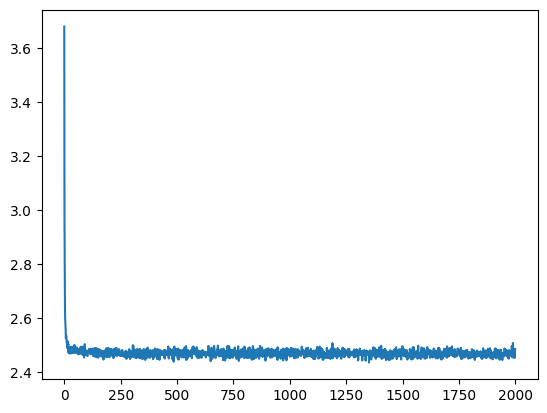

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

plt.figure()
plt.plot(all_losses)

## Try different temperatures

Changing the distribution sharpness has an impact on character sampling:

more or less probable things are sampled

In [7]:
print(generate(model,'T', 200, temperature=1))
print("----")
print(generate(model,'Th', 200, temperature=0.8))
print("----")

print(generate(model,'Th', 200, temperature=0.5))
print("----")

print(generate(model,'Th', 200, temperature=0.3))
print("----")

print(generate(model,'Th', 200, temperature=0.1))

Twhou wh che t'Haleawest hafo hiloumonkewe, bla par hed,
R:
I ike on wnyote;
I befout beret vas, wese.
IAle ant he burioor arren toneves s d hayor s.
Tnor s, beds ot t y fre sthale k sthedive:
ARYothem
----
Therg bto hesh buik we I t this uerofang al ar wat Fegentinco is bl Andy ce t he g ld chiloue st. lod bllo me, ane n, tr k, cero anchad
YCl ke opeeal he s have o m say ld wiveve wnd t par he yaind al yo
----
The s thar beve ha hesard g ar thas t win me anther than hind y mou all in t ou he yo lour I d f hin hall he ononour to a achial urs ce t are ber f whet ke r hy t d prthe ato benoret my we t hor t toure
----
The be t wo t t t the t an an o me s he I ar sour g be my he n he s in to he the n t in t s and he thare y ar me he t are t s men ave h the t he the ar ar t ar t he t t ave the t t me there hathe her ha
----
The the t the t t the the he t s the t t the t t t t t the the t the s t t t t t t the he the t t he t he the he he he t t he t t he t t t the s t the he t he t t the t 

### Improving this code:

(a) Tinker with parameters:

- Is it really necessary to have 100 dims character embeddings
- Chunk length can be gradually increased
- Try changing RNN cell type (GRUs - LSTMs)

(b) Add GPU support to go faster


In [14]:
# gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## GRU

 2s (100 0%) 4.6354]
Whp|qW`53b0|g
zn#jv6}LpOVQ~F!j?e8lYZz'({Tpa8ZBW`f_B^LqYyySP^<-[]\\Pq.Q|-nt|[&ey#<{-ih"!WK[9r=jD/n6#?-7 

 4s (200 1%) 4.6310]
WhVRD/7I<UMFzEjM$Wy/Cp^rh!rY`4Bb\2m!WUsn0y03ROFs" ~>QNMoBpjI~Twub/
-oSdIEJF	S\U%);gz*/0wqx*,y{uoE7_e 

 6s (300 1%) 4.6395]
H-0n]$!W\>'(Tsd"KVJN8a"v7>u{S}E
>ku&s96eiSP ieN=6?S=YMuaw_jBMjw.$CRg/eCc9RLUwV

 8s (400 2%) 4.6394]
Whbxr&)o=foIFJ3KHt~W[x6B$u|-3.j
HpX2q<YX^+TC]U*x ZIu!*yd,wjFbt:#

 10s (500 2%) 4.6375]
WhT&jNI^r?qBGE=}Vs(r#eO.x}Ec@oAsI=s.m WTU`akq^2JC@jW

]Q><z2(DxY2`}LHSes/j7]#a2Q[0WDbptb:9l7pOO4LB*&) 

 12s (600 3%) 4.6349]
Wh>6(^*os;mfv%YscbQ9"w{ep!"[R Zxl~C>0.z4V	}"MRHP.'0oe+u]_R_98FB#ppU1xt,fq]GL5_W!V|@y0zW/x~xK!p"!)6 

 14s (700 3%) 4.6328]
SD/|.WN[&AN F2@=I?{;(	zcd	PAOmuIX)_^[ypYPp6U

 16s (800 4%) 4.6365]
WhJ_{yHFk!jn&[$;l2NDQ]u1</Y3fZ*(:	6bQZ1jDh#tY0`	Nx7%@Q_\p{Z1s`vw$$$n704[V7cwZsx)C;1r<lX\LJ~+l=fdR:.X 

 18s (900 4%) 4.6367]
.PRPlUP/PqfAooKx1x\TT$pM	u9T6=tuekt{s2
c)J I>#S[yMCPDL:(4~k)}E"`o^`nITsWSG5@3e6A]5:2

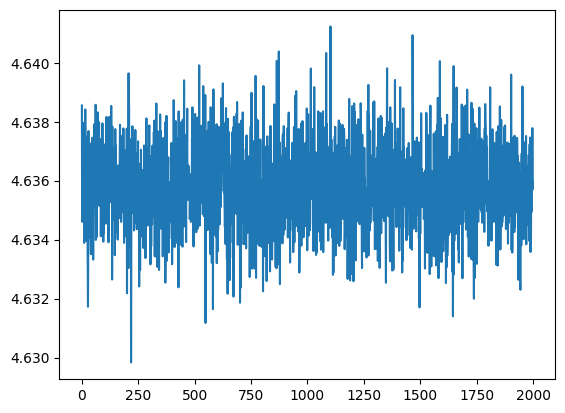

In [19]:
#### GRU

###Parameters
n_epochs = 20000
print_every = 100
plot_every = 10
hidden_size = 60 # lower
n_layers = 3
lr = 0.0005
batch_size = 16
chunk_len = 100 # more

####

gru = RNN(n_characters, hidden_size, n_characters, n_layers,rnn_cell=nn.GRU).to(device)
gru_optimizer = torch.optim.Adam(gru.parameters(), lr=lr) #create Adam optimizer
criterion = nn.CrossEntropyLoss() #chose criterion


start = time.time()
all_losses = []
loss_avg = 0

for epoch in range(1, n_epochs + 1):
    loss = train(gru,*random_training_set(chunk_len,batch_size))  #train on one chunk
    loss_avg += loss
    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))
        print(generate(gru,device,'Wh', 100), '\n')
    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0


plt.figure()
plt.plot(all_losses)

## LSTM

In [18]:
#### LSTM

###Parameters
n_epochs = 20000
print_every = 100
plot_every = 10
hidden_size = 30 # lower
n_layers = 5
lr = 0.0005
batch_size = 16
chunk_len = 120 # more

####model

lstm = RNN(n_characters, hidden_size, n_characters, n_layers,rnn_cell=nn.LSTM).to(device)
lstm_optimizer = torch.optim.Adam(lstm.parameters(), lr=lr) #create Adam optimizer

criterion = nn.CrossEntropyLoss() #chose criterion

start = time.time()
all_losses = []
loss_avg = 0

for epoch in range(1, n_epochs + 1):
    loss = train(lstm,*random_training_set(chunk_len,batch_size))  #train on one chunk
    loss_avg += loss
    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))
        print(generate(lstm,device,'Wh', 100), '\n')
    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0

plt.figure()
plt.plot(all_losses)


 2s (100 0%) 4.6145]
Wh]ifWkiD'4BPFnP,I^FcD \ea.tn}fT%9_1<v*9H}t7rC/@=\YLTL~(sSVlxD7Se%|]n_^;C/KoB`?$9DT):H0	Oz/X'nc.r,E 

 4s (200 1%) 4.6172]
V}]@kkER	<@z6P Abg5[dI[E+_,Nc|\PGak($2dt0XrGt5D]bg_4yS[vc[N$1n86EYx&~96'DdS8{fpJ/-d

 7s (300 1%) 4.6163]
y11Zq1;<ZDeMKH$A\H.HYAgGgDKlL`M(RE)EiC9IvDX6{9s~CvV'gZO+uPA=Bx	B+Vj 

 9s (400 2%) 4.6204]
Wh!z Ho,Q\TF|k 3,gT6	hhBB3}	9&6r{]V>5U51W,LS4=8*I%VgH8CVgiq
V|HgT z`_V^u*l;?=Q~15nHRZDABV&i<Wn))A  

 11s (500 2%) 4.6150]
Wh%\j>X&Q-[\E1j#!|ro><!$Hq^?tp{}7 /iC>4e[;%K?,a%Ajr<b"*9`ZfnS8UnDwN6=pV+1\}'BU}.BwD`PH=*g	3+$M`Taxg 

 14s (600 3%) 4.6131]
WhlY)
\.)jWP4XBS1mgkq/XrcC5TnjB+Z>>'8lMh)u;|3,	SX,~_E=],{_?CflO]`)woh [,{DLq?	ohO\@0zIfvP?{sVCdkT.\F 

 16s (700 3%) 4.6163]
X{u+xn~3YD` S'94~@^P7~\aQu*x/jHj/}2bA~v*uV"lK3[[ w0GPM	ZBY03]*6;K=pzt8x1}cu Zy%fE=p.~xkk3>

 18s (800 4%) 4.6134]
Whn.*bj)n
*5>zSg?#iU;4S``T..$VRq{v$w*P (9+bf*MOcjVW^$<>Dvk]`/]lB

 20s (900 4%) 4.6172]
S#{, V$76$J4d:Fp:vpk\zU#ljoW\	BGg`r\$.o(1X*\2'i|,~C6AA6g\Z{D,hK9{.

KeyboardInterrupt: 